# EDA — Gestión Dinámica de Carteras con TTS-GAN y RL
**TFM — Universidad Internacional de La Rioja (UNIR)**  
Autores: José Ángel Marrero Domínguez, Marco Napierski  
Periodo: 2004-01-01 → 2025-12-31  
Activos: S&P 500 · MSCI EAFE · MSCI EM · Oro · Petróleo WTI · Bono EEUU 10Y

---
### Contenido
1. Instalación y configuración
2. Descarga de datos con `yfinance`
3. Estadísticos descriptivos
4. Tests de normalidad (Jarque-Bera) y estacionariedad (ADF)
5. Test de Ljung-Box — efecto GARCH
6. Visualización de precios, retornos y volatilidad
7. Clasificación de regímenes (VIX)
8. Matrices de correlación por régimen
9. Distribuciones y Q-Q plots
10. Drawdown acumulado
11. ACF de retornos cuadráticos
12. Exportación de figuras y tabla-resumen

## 1 — Instalación y configuración

In [1]:
# Instalar dependencias si no están disponibles
# (ejecutar solo la primera vez)
%pip install yfinance pandas numpy scipy statsmodels matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf

from scipy import stats
from scipy.stats import jarque_bera, kurtosis, skew
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.stats.diagnostic import acorr_ljungbox

import os
np.random.seed(42)

# Directorio de salida para figuras
OUT = 'figuras_eda'
os.makedirs(OUT, exist_ok=True)

# Estilo de figuras
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2 — Descarga de datos con yfinance

In [6]:
# ─── Tickers de Yahoo Finance ───────────────────────────────────────────────
TICKERS = {
    'SP500':     '^GSPC',   # S&P 500
    'MSCI_EAFE': 'EFA',     # iShares MSCI EAFE ETF (proxy MSCI EAFE)
    'MSCI_EM':   'EEM',     # iShares MSCI Emerging Markets ETF
    'Gold':      'GLD',     # SPDR Gold Shares
    'Oil_WTI':   'USO',     # United States Oil Fund (proxy WTI)
    'UST10Y':    'IEF',     # iShares 7-10 Year Treasury Bond ETF
}
VIX_TICKER = '^VIX'

START = '2004-01-01'
END   = '2025-12-31'

# ─── Descarga ───────────────────────────────────────────────────────────────
print('Descargando precios de cierre ajustados...')
raw_prices = {}
for name, ticker in TICKERS.items():
    data = yf.download(ticker, start=START, end=END, auto_adjust=True, progress=False)
    raw_prices[name] = data['Close'].squeeze()
    print(f'  {name:12s} ({ticker}): {len(data)} días  |  {data.index[0].date()} → {data.index[-1].date()}')

prices = pd.DataFrame(raw_prices).dropna()

# VIX
vix_raw = yf.download(VIX_TICKER, start=START, end=END, auto_adjust=True, progress=False)
vix = vix_raw['Close'].squeeze().reindex(prices.index).ffill()

print(f'\nDataset final: {len(prices)} días  |  {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'Activos: {list(prices.columns)}')
prices.head()

Descargando precios de cierre ajustados...
  SP500        (^GSPC): 5534 días  |  2004-01-02 → 2025-12-30
  MSCI_EAFE    (EFA): 5534 días  |  2004-01-02 → 2025-12-30
  MSCI_EM      (EEM): 5534 días  |  2004-01-02 → 2025-12-30
  Gold         (GLD): 5312 días  |  2004-11-18 → 2025-12-30
  Oil_WTI      (USO): 4963 días  |  2006-04-10 → 2025-12-30
  UST10Y       (IEF): 5534 días  |  2004-01-02 → 2025-12-30

Dataset final: 4963 días  |  2006-04-10 → 2025-12-30
Activos: ['SP500', 'MSCI_EAFE', 'MSCI_EM', 'Gold', 'Oil_WTI', 'UST10Y']


,SP500,MSCI_EAFE,MSCI_EM,Gold,Oil_WTI,UST10Y
Date,,,,,,
2006-04-10,1296.619995,36.582294,22.336645,59.599998,544.159973,47.969936
2006-04-11,1286.569946,36.337639,22.146448,59.009998,545.599976,48.058811
2006-04-12,1288.119995,36.159702,22.274717,59.430000,542.719971,47.946228
2006-04-13,1289.119995,36.254230,22.380877,59.500000,550.559998,47.691338
2006-04-17,1285.329956,36.421040,22.646257,61.090000,558.320007,47.875099


In [4]:
# ─── Retornos logarítmicos diarios ─────────────────────────────────────────
returns = np.log(prices / prices.shift(1)).dropna()
vix = vix.reindex(returns.index).ffill()

# Etiquetas legibles para las figuras
LABELS = {
    'SP500':     'S&P 500',
    'MSCI_EAFE': 'MSCI EAFE',
    'MSCI_EM':   'MSCI Emerging Markets',
    'Gold':      'Oro',
    'Oil_WTI':   'Petróleo WTI',
    'UST10Y':    'Bono EEUU 10Y',
}

COLORS = {
    'SP500':     '#1f77b4',
    'MSCI_EAFE': '#ff7f0e',
    'MSCI_EM':   '#2ca02c',
    'Gold':      '#d4ac0d',
    'Oil_WTI':   '#8B0000',
    'UST10Y':    '#17becf',
}

# Periodos de crisis para sombrear figuras
CRISIS = {
    'GFC 2008':          ('2008-09-01', '2009-03-31', '#d62728'),
    'COVID-19 2020':     ('2020-02-20', '2020-04-30', '#9467bd'),
    'Ucrania 2022':      ('2022-02-24', '2022-09-30', '#e377c2'),
    'Crisis bancaria 23':('2023-03-08', '2023-05-31', '#bcbd22'),
}

NAMES = list(returns.columns)
print(f'Retornos calculados: {returns.shape}  (filas × activos)')
returns.describe().round(5)

Retornos calculados: (4962, 6)  (filas × activos)


,SP500,MSCI_EAFE,MSCI_EM,Gold,Oil_WTI,UST10Y
count,4962.00000,4962.00000,4962.00000,4962.00000,4962.00000,4962.00000
mean,0.00034,0.00020,0.00018,0.00038,-0.00041,0.00014
std,0.01237,0.01358,0.01759,0.01125,0.02316,0.00434
min,-0.12765,-0.11837,-0.17633,-0.09191,-0.29189,-0.02539
25%,-0.00408,-0.00536,-0.00764,-0.00514,-0.01195,-0.00246
50%,0.00074,0.00070,0.00083,0.00057,0.00061,0.00024
75%,0.00579,0.00654,0.00832,0.00622,0.01216,0.00265
max,0.10957,0.14745,0.20514,0.10697,0.15415,0.03369


## 3 — Estadísticos descriptivos

In [7]:
def compute_descriptive_stats(returns):
    """Calcula estadísticos descriptivos anualizados para cada activo."""
    rows = []
    for col in returns.columns:
        r = returns[col].dropna()
        n = len(r)

        # Jarque-Bera
        jb_stat, jb_p = jarque_bera(r)

        # ADF (estacionariedad)
        adf_stat, adf_p, *_ = adfuller(r, maxlag=10, autolag='AIC')

        # Ljung-Box sobre retornos cuadráticos (efecto GARCH)
        lb_result = acorr_ljungbox(r**2, lags=10, return_df=True)
        lb_stat10 = lb_result['lb_stat'].iloc[-1]
        lb_p10    = lb_result['lb_pvalue'].iloc[-1]

        rows.append({
            'Activo':              LABELS[col],
            'Media anual (%)':     round(r.mean() * 252 * 100, 2),
            'Volat. anual (%)':    round(r.std() * np.sqrt(252) * 100, 2),
            'Sesgo':               round(float(skew(r)), 4),
            'Curtosis exceso':     round(float(kurtosis(r, fisher=True)), 4),
            'Mín. diario (%)':     round(r.min() * 100, 2),
            'Máx. diario (%)':     round(r.max() * 100, 2),
            'Sharpe anual':        round(r.mean() * 252 / (r.std() * np.sqrt(252)), 3),
            'JB stat':             round(jb_stat, 2),
            'JB p-valor':          f'{jb_p:.2e}',
            'ADF stat':            round(adf_stat, 4),
            'ADF p-valor':         round(adf_p, 4),
            'LB²(10) stat':        round(lb_stat10, 2),
            'LB²(10) p-valor':     f'{lb_p10:.2e}',
        })

    df = pd.DataFrame(rows).set_index('Activo')
    return df


desc = compute_descriptive_stats(returns)

# Mostrar tabla con estilo
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
print('=== ESTADÍSTICOS DESCRIPTIVOS ===')
desc

=== ESTADÍSTICOS DESCRIPTIVOS ===


,Media anual (%),Volat. anual (%),Sesgo,Curtosis exceso,Mín. diario (%),Máx. diario (%),Sharpe anual,JB stat,JB p-valor,ADF stat,ADF p-valor,LB²(10) stat,LB²(10) p-valor
Activo,,,,,,,,,,,,,
S&P 500,8.49,19.63,-0.4752,12.7365,-12.77,10.96,0.432,33725.59,0.00e+00,-23.7744,0.0,4802.50,0.00e+00
MSCI EAFE,4.92,21.56,-0.3574,13.3628,-11.84,14.75,0.228,37023.58,0.00e+00,-30.8173,0.0,3959.51,0.00e+00
MSCI Emerging Markets,4.57,27.92,0.0545,16.1478,-17.63,20.51,0.163,53912.91,0.00e+00,-31.7966,0.0,5283.10,0.00e+00
Oro,9.65,17.85,-0.3403,5.9667,-9.19,10.70,0.541,7456.33,0.00e+00,-71.2733,0.0,614.48,1.39e-125
Petróleo WTI,-10.43,36.76,-1.1020,13.9175,-29.19,15.42,-0.284,41050.78,0.00e+00,-25.2905,0.0,1391.54,6.65e-293
Bono EEUU 10Y,3.48,6.89,0.1105,2.6450,-2.54,3.37,0.505,1456.49,0.00e+00,-52.8598,0.0,1089.85,8.13e-228


In [8]:
# ─── Guardar tabla como CSV ─────────────────────────────────────────────────
desc.to_csv(f'{OUT}/tabla_estadisticos_descriptivos.csv')
print('Tabla guardada →', f'{OUT}/tabla_estadisticos_descriptivos.csv')

Tabla guardada → figuras_eda/tabla_estadisticos_descriptivos.csv


## 4 — Tests de normalidad (Jarque-Bera) y estacionariedad (ADF)

In [9]:
print('=' * 72)
print(f'{"ACTIVO":22s} {"JB stat":>12s} {"JB p-val":>12s} {"ADF stat":>10s} {"ADF p-val":>10s}')
print('-' * 72)
for col in NAMES:
    r = returns[col].dropna()
    jb_s, jb_p = jarque_bera(r)
    adf_s, adf_p, *_ = adfuller(r, maxlag=10, autolag='AIC')
    norm_flag = '✗ NO NORMAL' if jb_p < 0.05 else '✓ Normal'
    stat_flag = '✓ Estacionaria' if adf_p < 0.05 else '✗ NO Estacionaria'
    print(f'{LABELS[col]:22s} {jb_s:12.2f} {jb_p:12.2e}  {adf_s:10.4f} {adf_p:10.4f}  {norm_flag}  {stat_flag}')
print('=' * 72)
print('Interpretación:')
print('  JB p < 0.05  → Rechaza normalidad (fat tails / asimetría presente)')
print('  ADF p < 0.05 → Estacionaria (adecuada para modelos de series temporales)')

ACTIVO                      JB stat     JB p-val   ADF stat  ADF p-val
------------------------------------------------------------------------
S&P 500                    33725.59     0.00e+00    -23.7744     0.0000  ✗ NO NORMAL  ✓ Estacionaria
MSCI EAFE                  37023.58     0.00e+00    -30.8173     0.0000  ✗ NO NORMAL  ✓ Estacionaria
MSCI Emerging Markets      53912.91     0.00e+00    -31.7966     0.0000  ✗ NO NORMAL  ✓ Estacionaria
Oro                         7456.33     0.00e+00    -71.2733     0.0000  ✗ NO NORMAL  ✓ Estacionaria
Petróleo WTI               41050.78     0.00e+00    -25.2905     0.0000  ✗ NO NORMAL  ✓ Estacionaria
Bono EEUU 10Y               1456.49     0.00e+00    -52.8598     0.0000  ✗ NO NORMAL  ✓ Estacionaria
Interpretación:
  JB p < 0.05  → Rechaza normalidad (fat tails / asimetría presente)
  ADF p < 0.05 → Estacionaria (adecuada para modelos de series temporales)


## 5 — Test de Ljung-Box — efecto GARCH (agrupamiento de volatilidad)

In [10]:
print('=' * 70)
print(f'{"ACTIVO":22s} {"LB²(10) stat":>14s} {"LB²(10) p-val":>14s} {"GARCH effect":>14s}')
print('-' * 70)
for col in NAMES:
    r = returns[col].dropna()
    lb = acorr_ljungbox(r**2, lags=10, return_df=True)
    st = lb['lb_stat'].iloc[-1]
    pv = lb['lb_pvalue'].iloc[-1]
    flag = '✓ CONFIRMADO' if pv < 0.05 else '✗ No detectado'
    print(f'{LABELS[col]:22s} {st:14.2f} {pv:14.2e}  {flag}')
print('=' * 70)
print('LB² sobre r²: autocorrelación en la varianza → heterocedasticidad condicional (GARCH)')

ACTIVO                   LB²(10) stat  LB²(10) p-val   GARCH effect
----------------------------------------------------------------------
S&P 500                       4802.50       0.00e+00  ✓ CONFIRMADO
MSCI EAFE                     3959.51       0.00e+00  ✓ CONFIRMADO
MSCI Emerging Markets         5283.10       0.00e+00  ✓ CONFIRMADO
Oro                            614.48      1.39e-125  ✓ CONFIRMADO
Petróleo WTI                  1391.54      6.65e-293  ✓ CONFIRMADO
Bono EEUU 10Y                 1089.85      8.13e-228  ✓ CONFIRMADO
LB² sobre r²: autocorrelación en la varianza → heterocedasticidad condicional (GARCH)


## 6 — Visualización: precios, retornos y volatilidad

In [11]:
# ─── Función auxiliar: sombrear crisis ────────────────────────────────────
def shade_crisis(ax, alpha=0.12):
    ylims = ax.get_ylim()
    for label, (start, end, color) in CRISIS.items():
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=alpha, color=color, zorder=0)
    ax.set_ylim(ylims)  # restaurar por si axvspan los modifica

def format_xaxis(ax, freq=2):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(freq))
    ax.grid(alpha=0.3)

print('Funciones auxiliares definidas ✓')

Funciones auxiliares definidas ✓


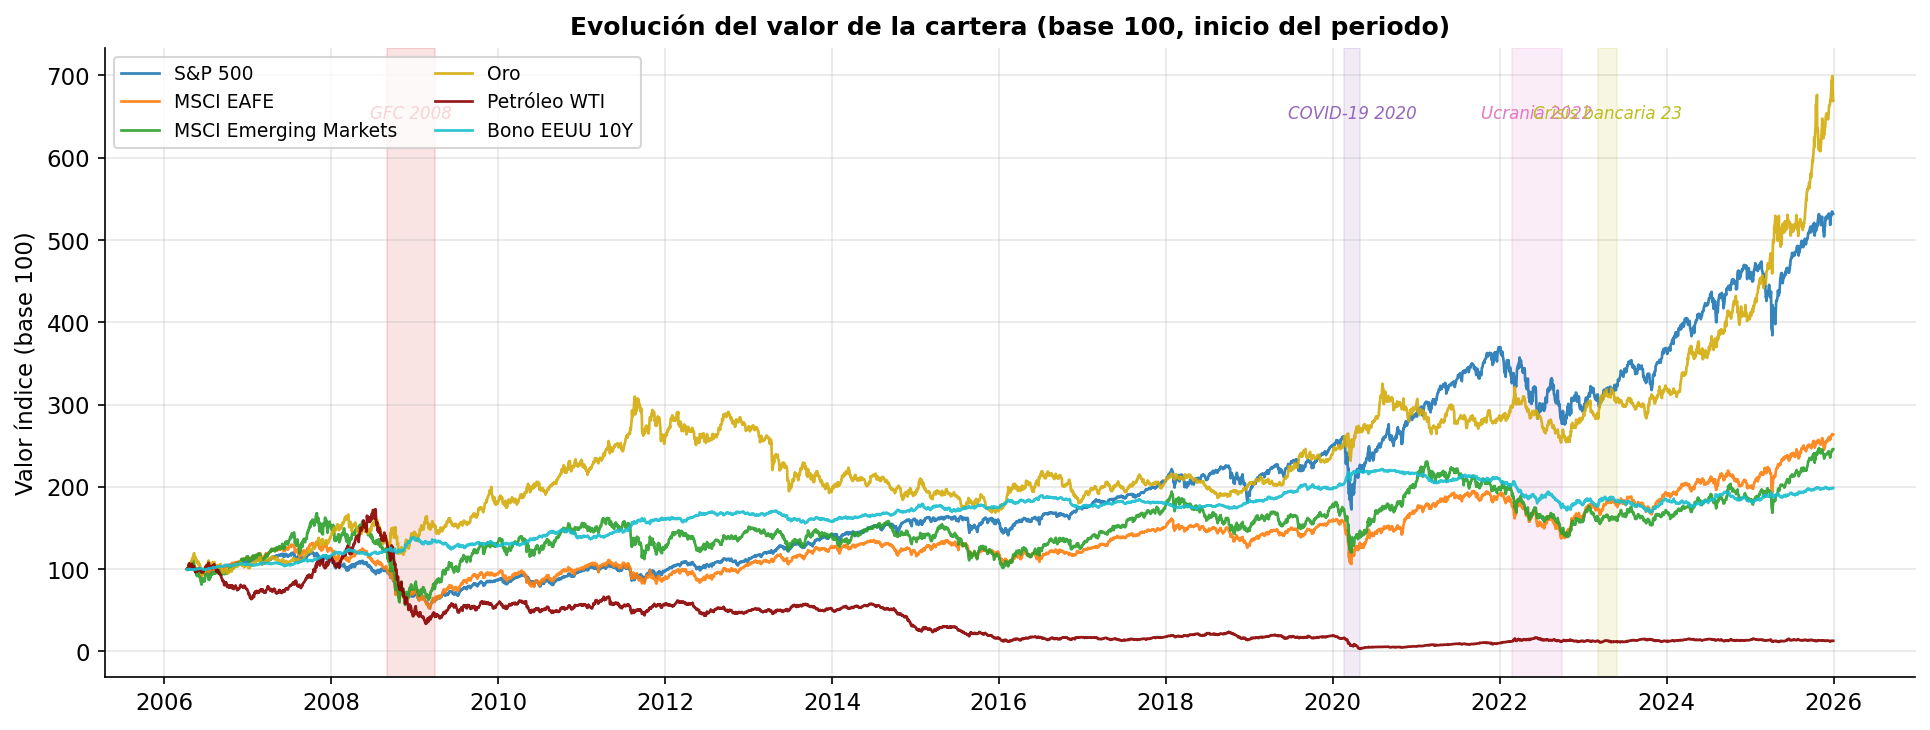

Fig 1 guardada ✓


In [12]:
# ─── Fig 1: Precios normalizados (base 100) ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

normalized = (prices / prices.iloc[0]) * 100
for col in NAMES:
    ax.plot(normalized.index, normalized[col],
            label=LABELS[col], color=COLORS[col], lw=1.3, alpha=0.9)

shade_crisis(ax, alpha=0.13)
for label, (start, end, color) in CRISIS.items():
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    y_top = normalized.values.max() * 0.95
    ax.text(mid, y_top, label, ha='center', va='top',
            fontsize=8, color=color, style='italic')

ax.set_title('Evolución del valor de la cartera (base 100, inicio del periodo)', fontweight='bold')
ax.set_ylabel('Valor índice (base 100)')
ax.legend(loc='upper left', ncol=2, fontsize=9)
format_xaxis(ax)
plt.tight_layout()
plt.savefig(f'{OUT}/fig1_precios_normalizados.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 1 guardada ✓')

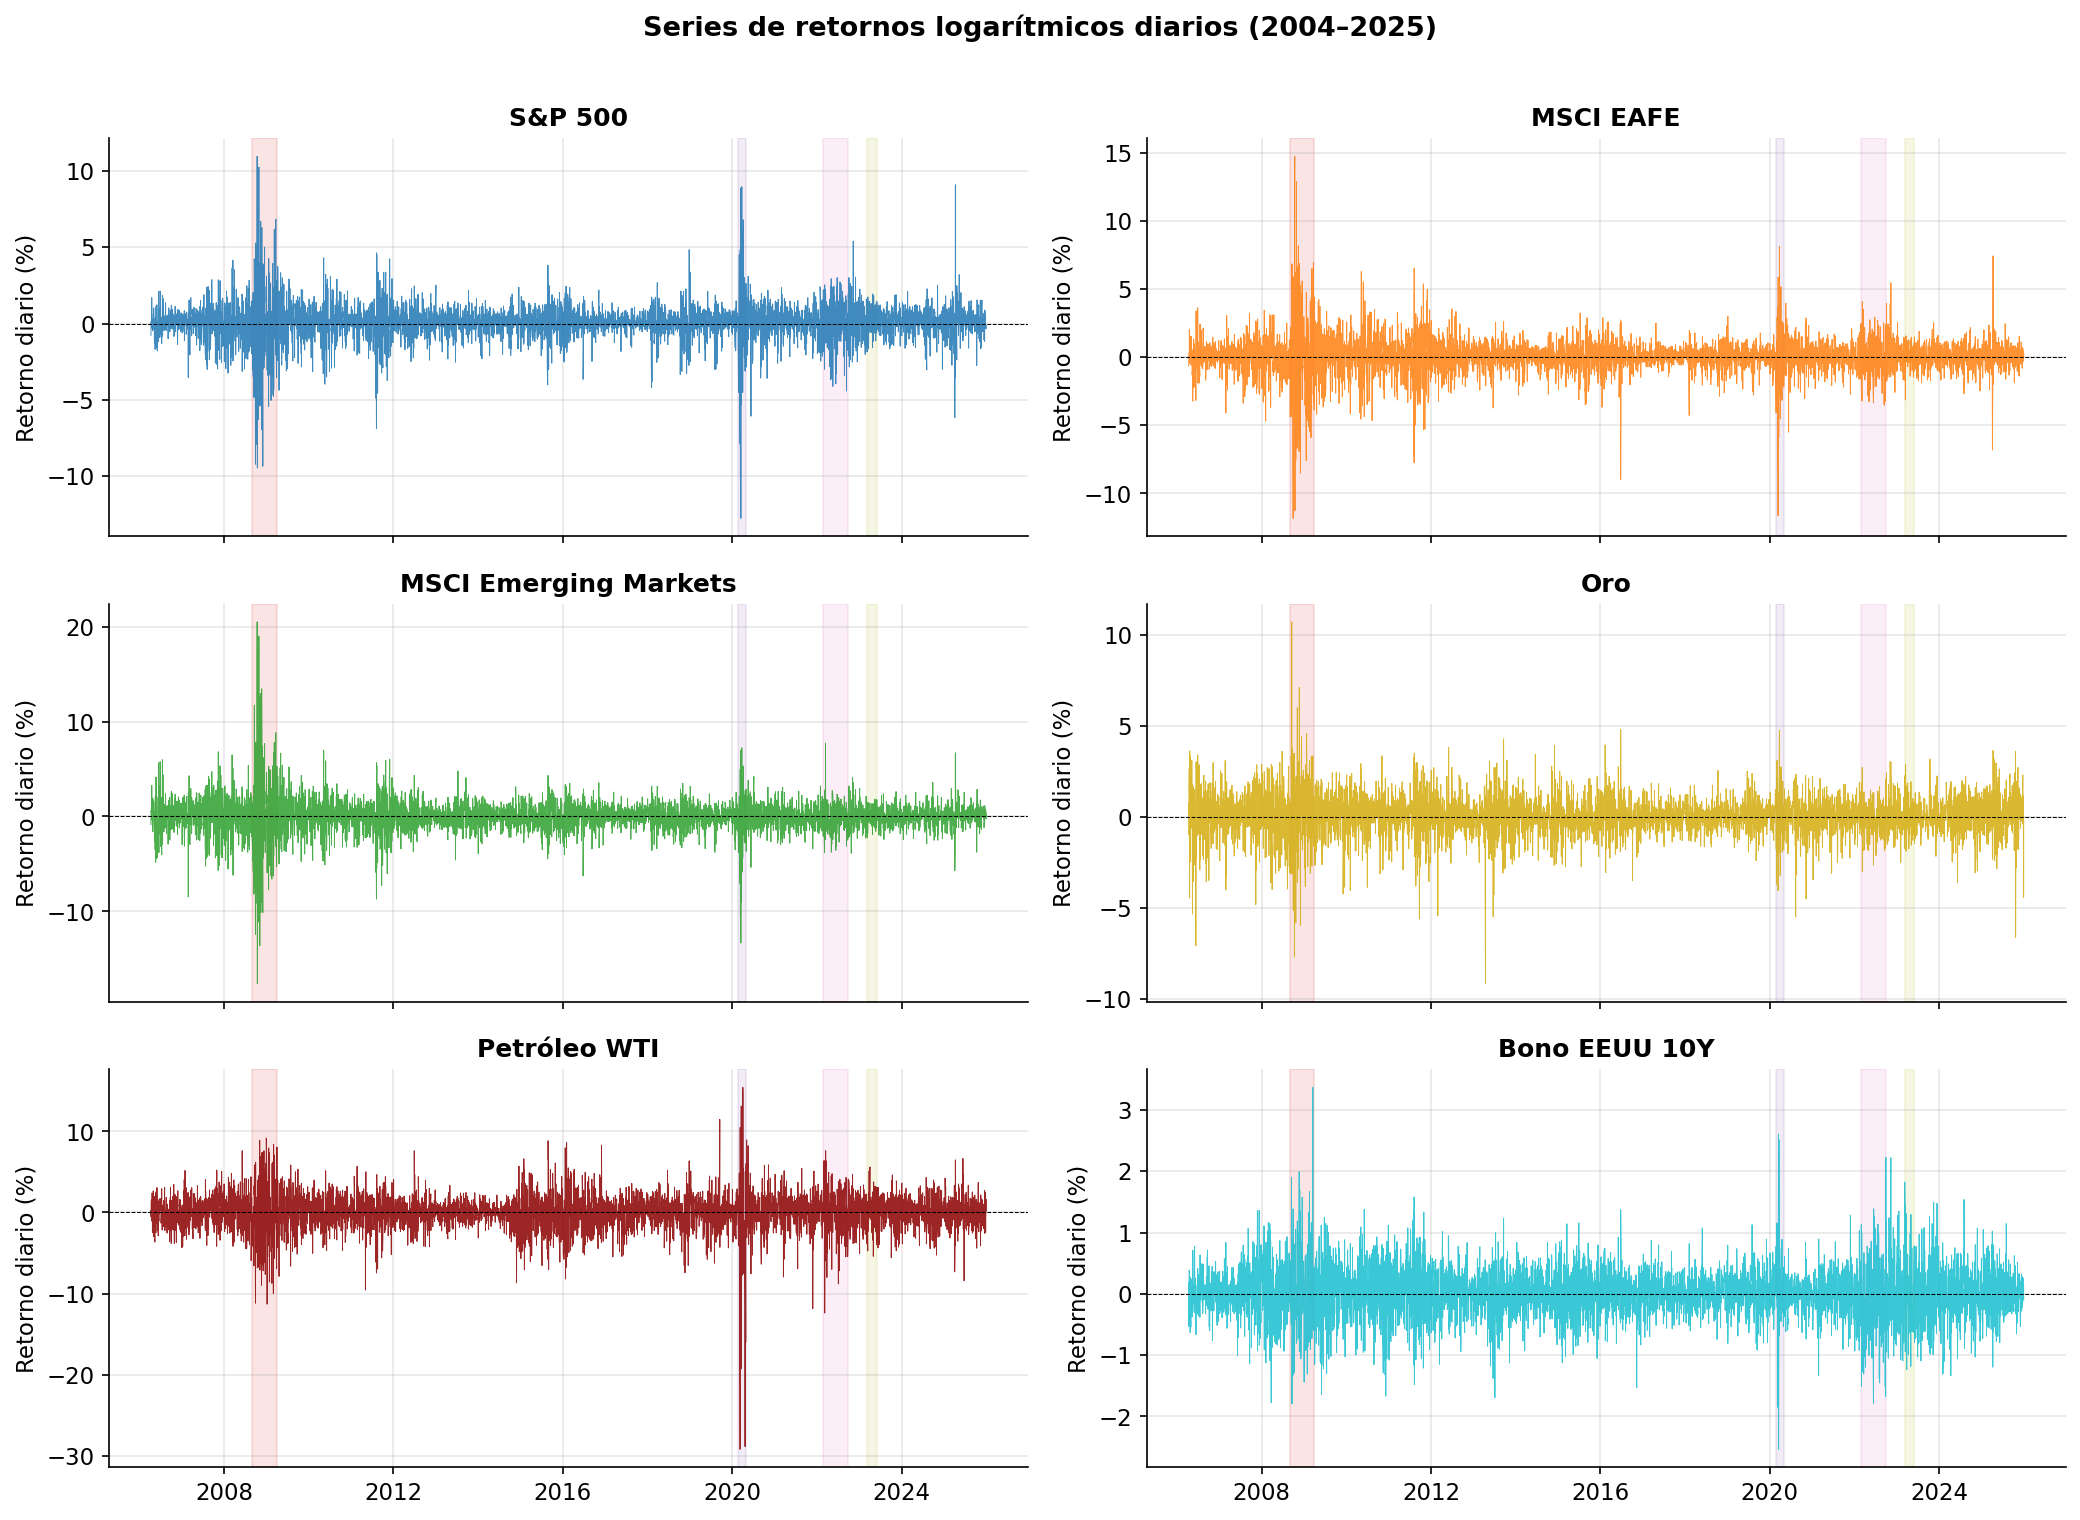

Fig 2 guardada ✓


In [13]:
# ─── Fig 2: Retornos diarios (6 subplots) ─────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(NAMES):
    ax = axes[i]
    ax.plot(returns.index, returns[col] * 100,
            color=COLORS[col], lw=0.45, alpha=0.85)
    ax.axhline(0, color='black', lw=0.5, ls='--')
    shade_crisis(ax, alpha=0.12)
    ax.set_title(LABELS[col], fontweight='bold')
    ax.set_ylabel('Retorno diario (%)')
    format_xaxis(ax, freq=4)

plt.suptitle('Series de retornos logarítmicos diarios (2004–2025)',
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT}/fig2_retornos_diarios.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 2 guardada ✓')

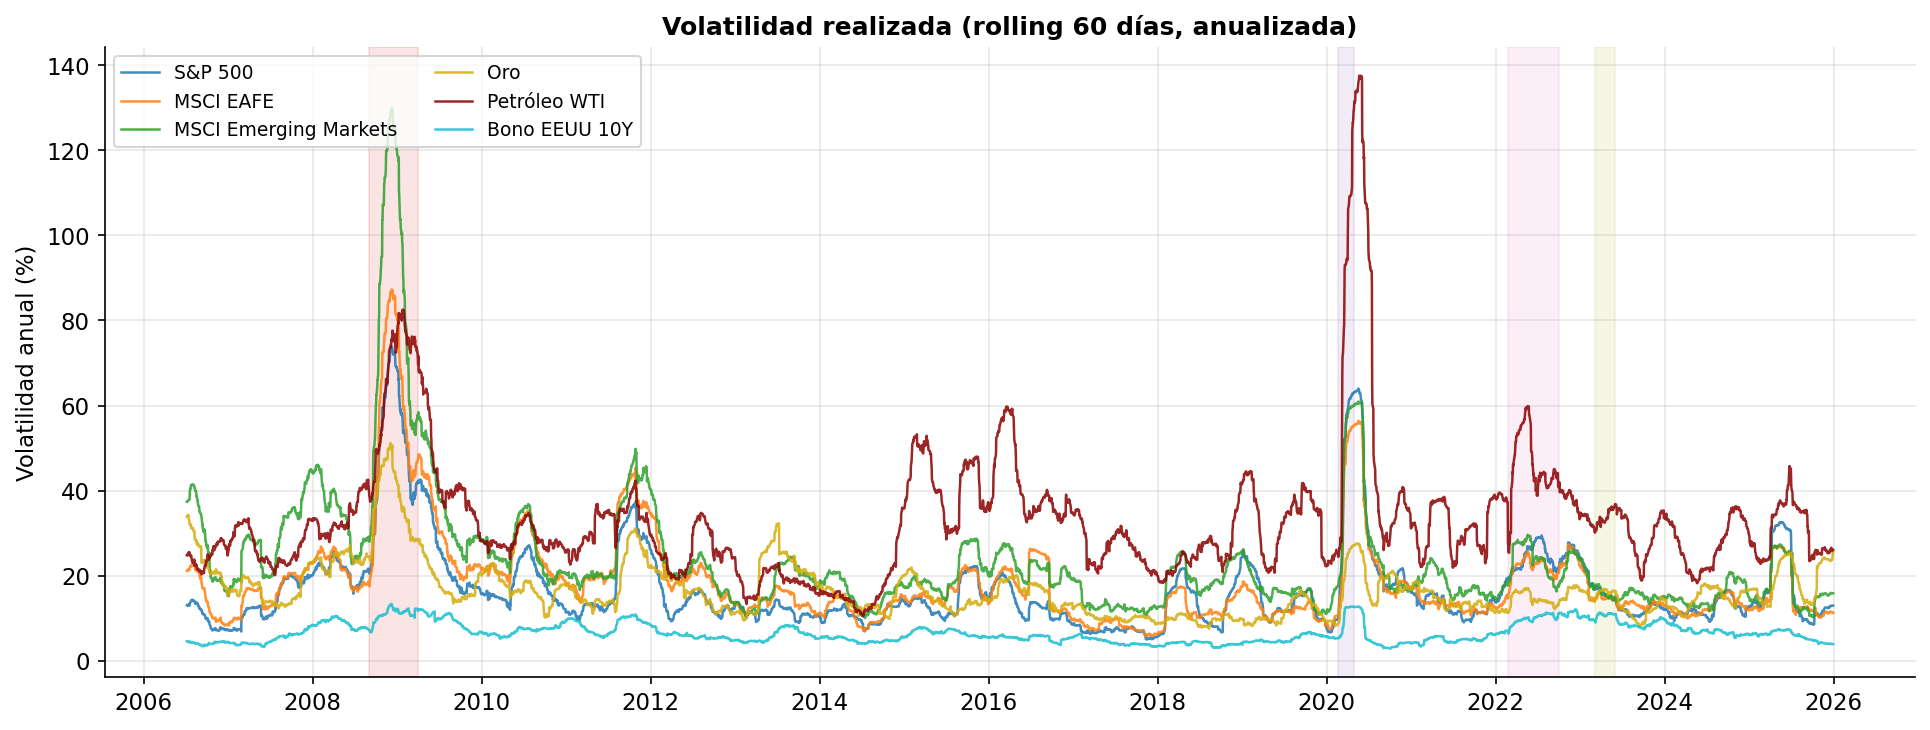

Fig 3 guardada ✓


In [14]:
# ─── Fig 3: Volatilidad realizada rolling 60 días ─────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

WINDOW = 60
for col in NAMES:
    roll_vol = returns[col].rolling(WINDOW).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol,
            label=LABELS[col], color=COLORS[col], lw=1.2, alpha=0.85)

shade_crisis(ax, alpha=0.12)
ax.set_title(f'Volatilidad realizada (rolling {WINDOW} días, anualizada)', fontweight='bold')
ax.set_ylabel('Volatilidad anual (%)')
ax.legend(ncol=2, fontsize=9, loc='upper left')
format_xaxis(ax)
plt.tight_layout()
plt.savefig(f'{OUT}/fig3_volatilidad_rolling.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 3 guardada ✓')

## 7 — Clasificación de regímenes por VIX

In [15]:
# ─── Clasificar régimen ────────────────────────────────────────────────────
def classify_regime(v):
    if v < 20:   return 'Baja volatilidad'
    elif v < 30: return 'Volatilidad moderada'
    else:        return 'Estrés financiero'

regime = vix.map(classify_regime)

# Estadísticas por régimen
counts = regime.value_counts()
total  = len(regime)
print('=== DISTRIBUCIÓN POR RÉGIMEN ===')
for r_name in ['Baja volatilidad', 'Volatilidad moderada', 'Estrés financiero']:
    n = counts.get(r_name, 0)
    print(f'  {r_name:25s}: {n:5d} días  ({n/total*100:5.1f}%)')
print(f'  {"Total":25s}: {total:5d} días  (100.0%)')

# Añadir régimen al dataframe de retornos
returns_r = returns.copy()
returns_r['regime'] = regime
returns_r['vix']    = vix

=== DISTRIBUCIÓN POR RÉGIMEN ===
  Baja volatilidad         :  3228 días  ( 65.1%)
  Volatilidad moderada     :  1287 días  ( 25.9%)
  Estrés financiero        :   447 días  (  9.0%)
  Total                    :  4962 días  (100.0%)


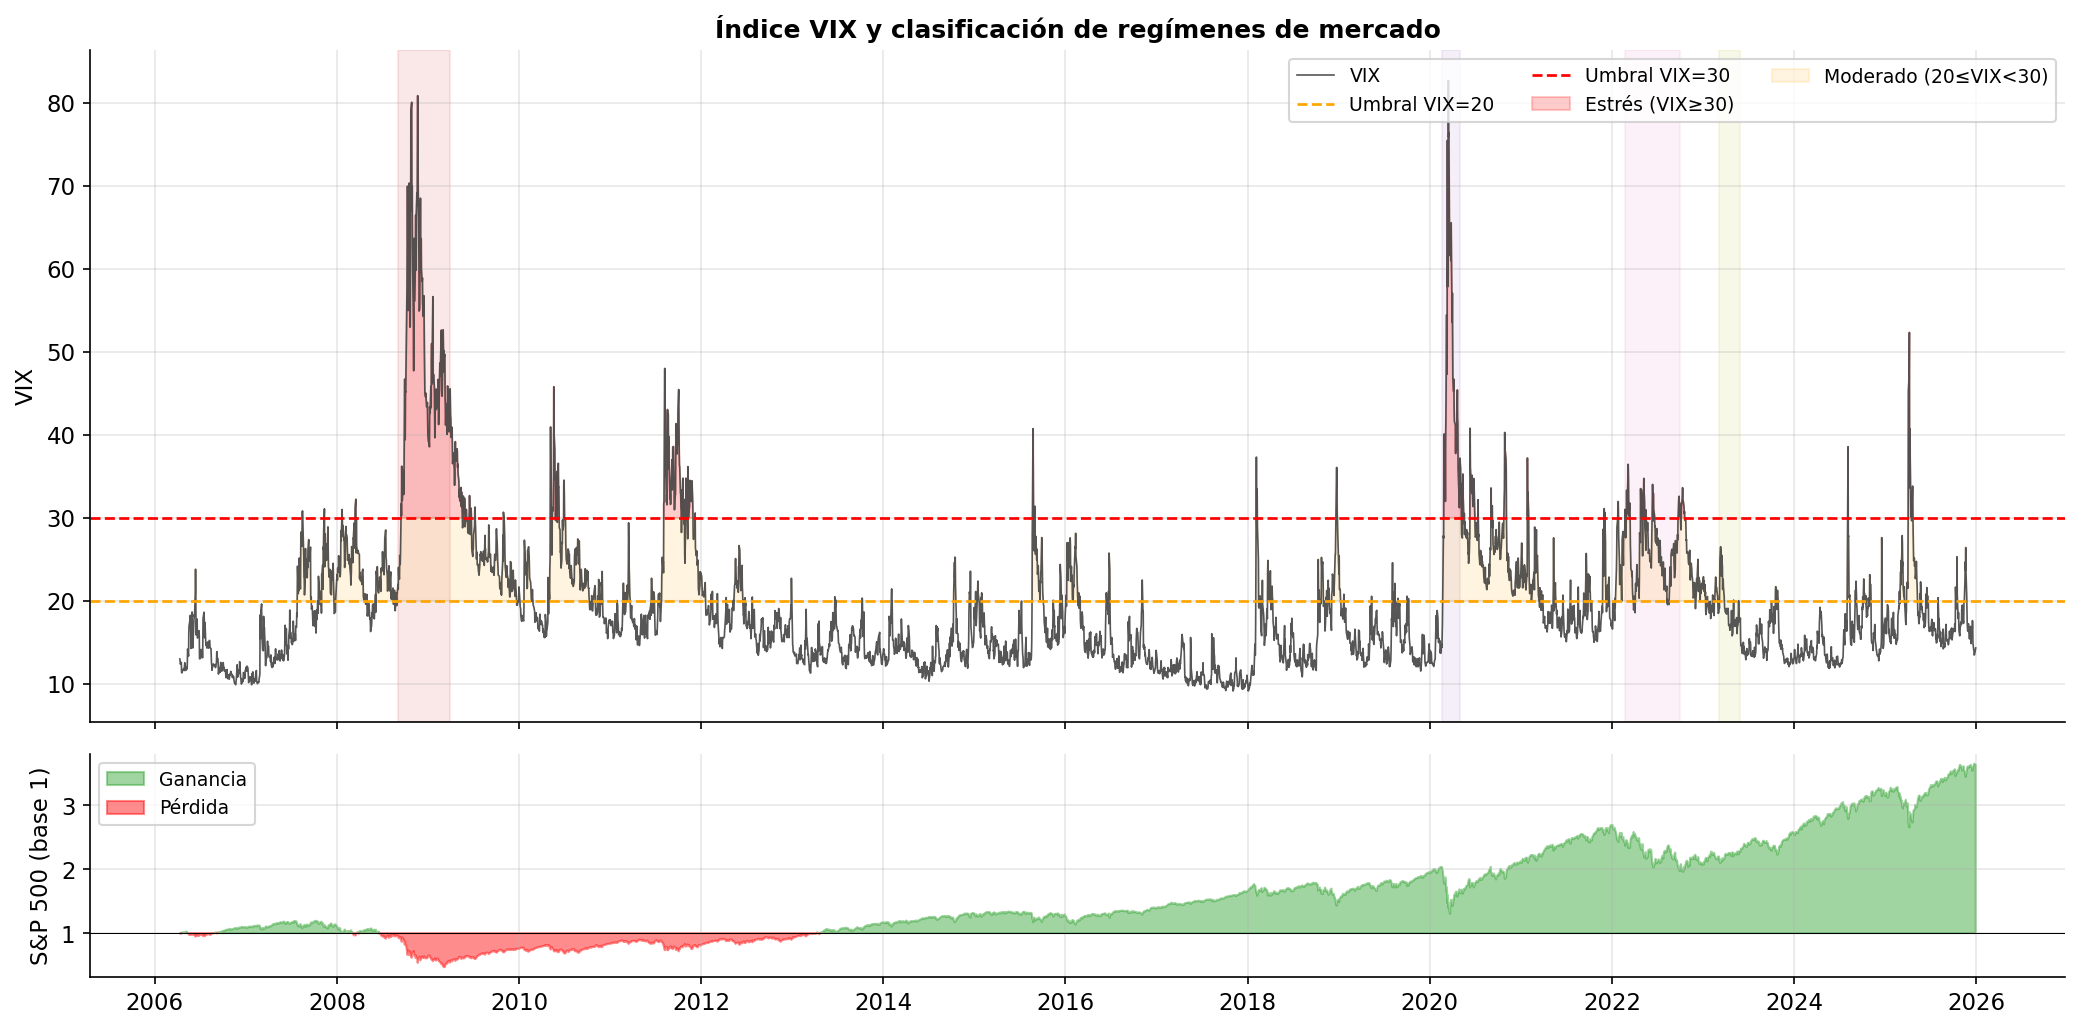

Fig 4 guardada ✓


In [16]:
# ─── Fig 4: VIX + régimen + S&P 500 ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                height_ratios=[3, 1])

ax1.plot(vix.index, vix.values, color='#444444', lw=0.8, alpha=0.9, label='VIX')
ax1.axhline(20, color='orange', lw=1.3, ls='--', label='Umbral VIX=20')
ax1.axhline(30, color='red',    lw=1.3, ls='--', label='Umbral VIX=30')
ax1.fill_between(vix.index, vix.values, 30,
                 where=vix.values > 30, color='red',    alpha=0.20, label='Estrés (VIX≥30)')
ax1.fill_between(vix.index, 20, np.minimum(vix.values, 30),
                 where=vix.values > 20, color='orange', alpha=0.12, label='Moderado (20≤VIX<30)')

shade_crisis(ax1, alpha=0.10)
ax1.set_ylabel('VIX')
ax1.set_title('Índice VIX y clasificación de regímenes de mercado', fontweight='bold')
ax1.legend(loc='upper right', fontsize=9, ncol=3)
ax1.grid(alpha=0.3)

sp500_cum = (1 + returns['SP500']).cumprod()
ax2.fill_between(sp500_cum.index, 1, sp500_cum.values,
                 where=sp500_cum.values >= 1, color='#2ca02c', alpha=0.45, label='Ganancia')
ax2.fill_between(sp500_cum.index, 1, sp500_cum.values,
                 where=sp500_cum.values  < 1, color='red',     alpha=0.45, label='Pérdida')
ax2.axhline(1, color='black', lw=0.5)
ax2.set_ylabel('S&P 500 (base 1)')
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(alpha=0.3)
format_xaxis(ax2)

plt.tight_layout()
plt.savefig(f'{OUT}/fig4_vix_regimen.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 4 guardada ✓')

In [17]:
# ─── Estadísticos por régimen para cada activo ────────────────────────────
regime_stats = []
for reg in ['Baja volatilidad', 'Volatilidad moderada', 'Estrés financiero']:
    mask = regime == reg
    for col in NAMES:
        r = returns.loc[mask, col]
        regime_stats.append({
            'Régimen': reg,
            'Activo':  LABELS[col],
            'Media anual (%)':   round(r.mean() * 252 * 100, 2),
            'Volat. anual (%)':  round(r.std() * np.sqrt(252) * 100, 2),
            'Sesgo':             round(float(skew(r)), 3),
            'Curtosis exc.':     round(float(kurtosis(r, fisher=True)), 3),
        })

df_regime_stats = pd.DataFrame(regime_stats)
print('=== ESTADÍSTICOS POR RÉGIMEN ===')
df_regime_stats

=== ESTADÍSTICOS POR RÉGIMEN ===


,Régimen,Activo,Media anual (%),Volat. anual (%),Sesgo,Curtosis exc.
0,Baja volatilidad,S&P 500,31.72,10.70,-0.100,1.308
1,Baja volatilidad,MSCI EAFE,26.08,12.76,-0.148,1.392
2,Baja volatilidad,MSCI Emerging Markets,23.82,17.57,-0.127,2.395
3,Baja volatilidad,Oro,5.79,15.36,-0.647,5.234
4,Baja volatilidad,Petróleo WTI,8.28,27.87,-0.188,2.008
5,Baja volatilidad,Bono EEUU 10Y,-0.25,5.64,-0.204,1.050
6,Volatilidad moderada,S&P 500,-14.36,20.34,0.030,0.355
7,Volatilidad moderada,MSCI EAFE,-13.12,22.25,-0.081,2.176
8,Volatilidad moderada,MSCI Emerging Markets,-5.91,27.76,0.077,1.264
9,Volatilidad moderada,Oro,19.97,18.30,-0.574,2.907


## 8 — Matrices de correlación por régimen

In [18]:
# ─── Calcular matrices de correlación ─────────────────────────────────────
mask_low    = regime == 'Baja volatilidad'
mask_mod    = regime == 'Volatilidad moderada'
mask_stress = regime == 'Estrés financiero'

corr_global = returns[NAMES].corr()
corr_low    = returns.loc[mask_low,    NAMES].corr()
corr_stress = returns.loc[mask_stress, NAMES].corr()

# Distancia de Frobenius entre regímenes extremos
frob = np.linalg.norm(corr_stress.values - corr_low.values, 'fro')
print(f'Distancia de Frobenius (corr_stress − corr_low) = {frob:.4f}')
print('Este valor debe ser reproducido por TTS-GAN en los datos sintéticos.')

Distancia de Frobenius (corr_stress − corr_low) = 1.0913
Este valor debe ser reproducido por TTS-GAN en los datos sintéticos.


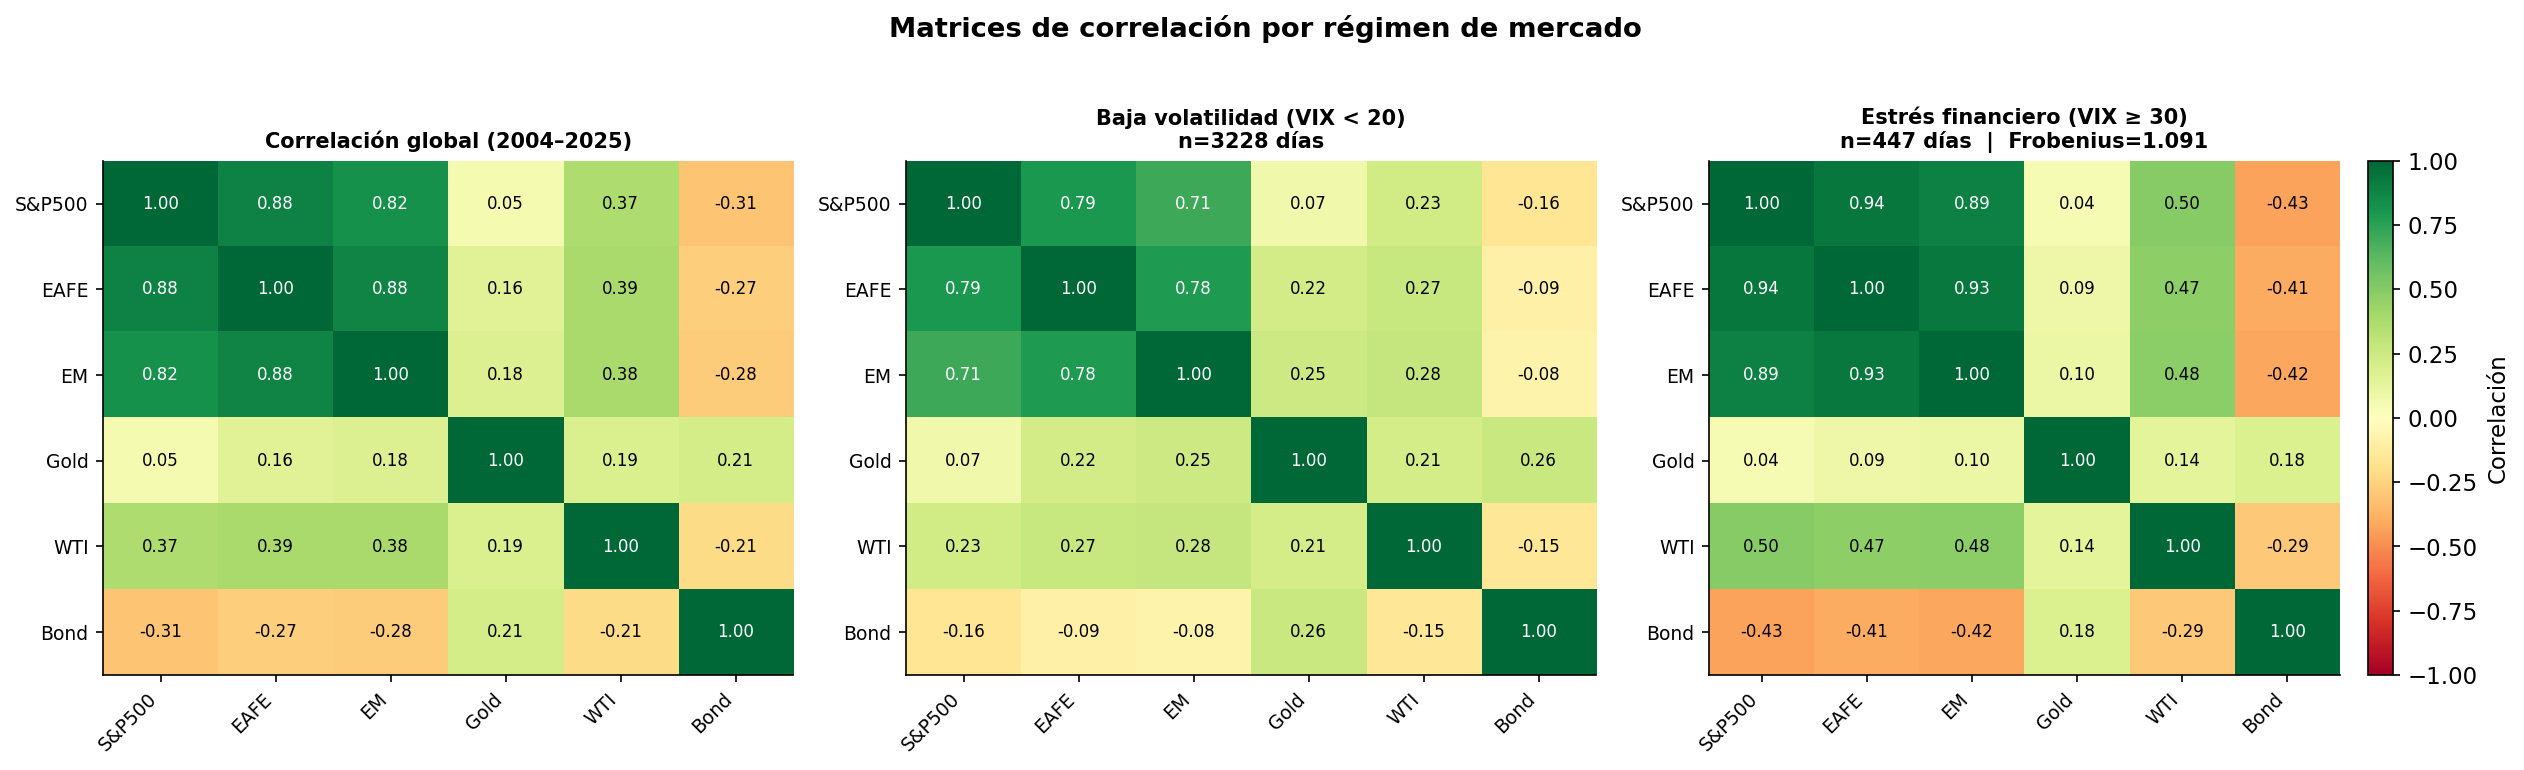

Fig 5 guardada ✓


In [19]:
# ─── Fig 5: Matrices de correlación ───────────────────────────────────────
SHORT = ['S&P500', 'EAFE', 'EM', 'Gold', 'WTI', 'Bond']
n_assets = len(NAMES)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
corr_list  = [corr_global, corr_low, corr_stress]
title_list = [
    f'Correlación global (2004–2025)',
    f'Baja volatilidad (VIX < 20)\nn={mask_low.sum()} días',
    f'Estrés financiero (VIX ≥ 30)\nn={mask_stress.sum()} días  |  Frobenius={frob:.3f}',
]

for ax, corr_mat, title in zip(axes, corr_list, title_list):
    im = ax.imshow(corr_mat.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_assets)); ax.set_xticklabels(SHORT, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(n_assets)); ax.set_yticklabels(SHORT, fontsize=9)
    for r in range(n_assets):
        for c in range(n_assets):
            val = corr_mat.values[r, c]
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < 0.7 else 'white')
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label='Correlación')
plt.suptitle('Matrices de correlación por régimen de mercado', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT}/fig5_correlaciones.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 5 guardada ✓')

In [20]:
# ─── Tabla: cambio de correlaciones entre regímenes ───────────────────────
pairs = [
    ('SP500', 'MSCI_EAFE'),
    ('SP500', 'MSCI_EM'),
    ('SP500', 'Gold'),
    ('SP500', 'Oil_WTI'),
    ('SP500', 'UST10Y'),
    ('MSCI_EAFE', 'MSCI_EM'),
    ('Gold', 'UST10Y'),
]

print(f'{'Par de activos':35s} {"Baja vol.":>10s} {"Global":>10s} {"Estrés":>10s} {"Δ":>8s}')
print('-' * 78)
for a, b in pairs:
    cl = corr_low.loc[a, b]
    cg = corr_global.loc[a, b]
    cs = corr_stress.loc[a, b]
    delta = cs - cl
    sign = '+' if delta >= 0 else ''
    label = f'{LABELS[a]} – {LABELS[b]}'
    print(f'{label:35s} {cl:10.3f} {cg:10.3f} {cs:10.3f} {sign}{delta:7.3f}')
print('-' * 78)
print(f'Frobenius (corr_stress − corr_low) = {frob:.4f}')

Par de activos                       Baja vol.     Global     Estrés        Δ
------------------------------------------------------------------------------
S&P 500 – MSCI EAFE                      0.792      0.884      0.937 +  0.145
S&P 500 – MSCI Emerging Markets          0.710      0.825      0.892 +  0.183
S&P 500 – Oro                            0.071      0.055      0.043  -0.029
S&P 500 – Petróleo WTI                   0.229      0.367      0.497 +  0.268
S&P 500 – Bono EEUU 10Y                 -0.163     -0.309     -0.432  -0.268
MSCI EAFE – MSCI Emerging Markets        0.784      0.875      0.928 +  0.145
Oro – Bono EEUU 10Y                      0.258      0.212      0.180  -0.078
------------------------------------------------------------------------------
Frobenius (corr_stress − corr_low) = 1.0913


## 9 — Distribuciones y Q-Q plots

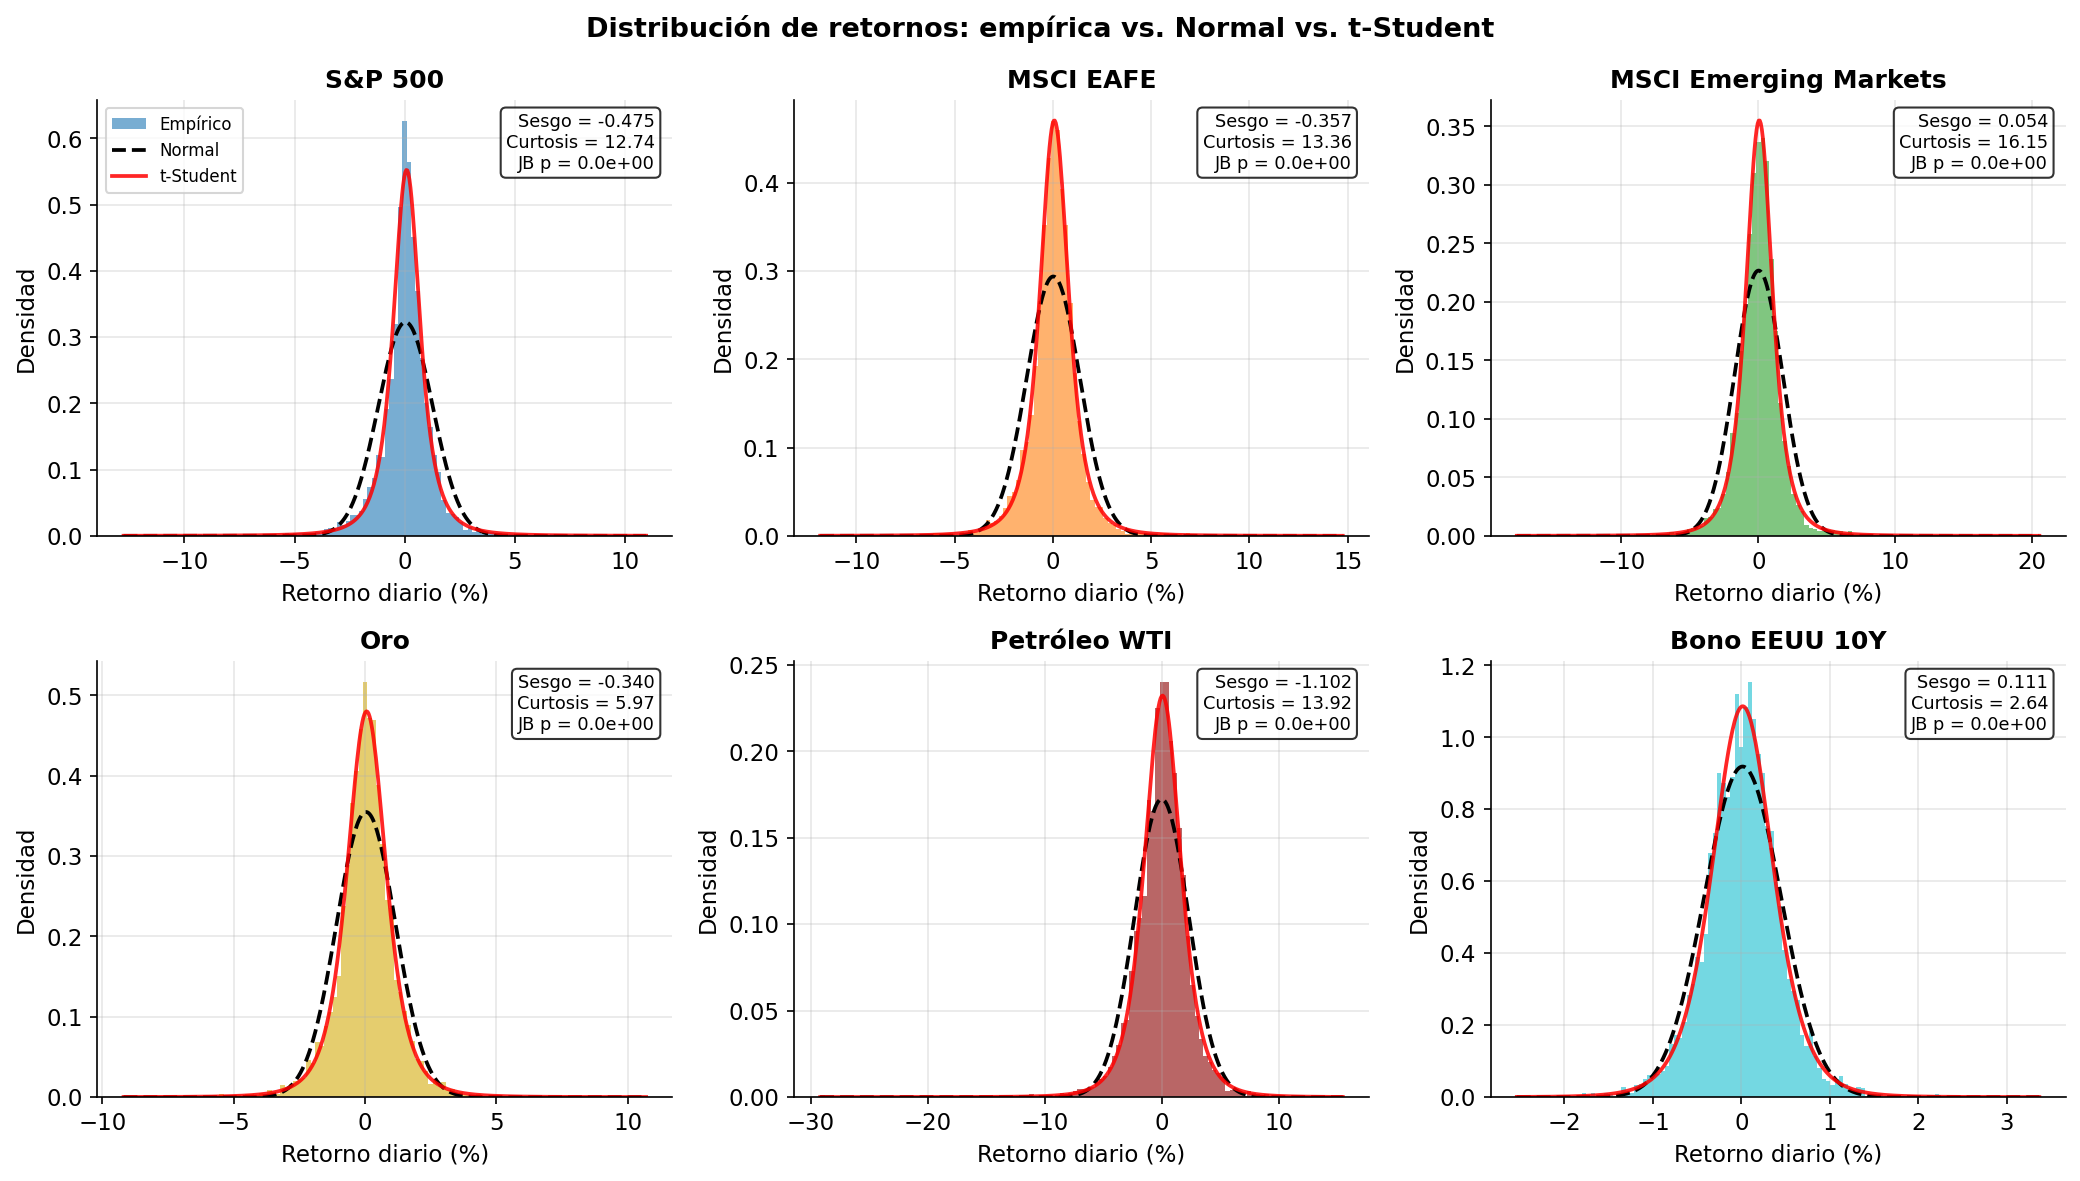

Fig 6 guardada ✓


In [21]:
# ─── Fig 6: Histogramas + Normal fit + t-Student fit ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NAMES):
    ax = axes[i]
    r  = returns[col].values * 100

    ax.hist(r, bins=120, density=True,
            color=COLORS[col], alpha=0.60, label='Empírico')

    # Ajuste Normal
    mu_n, sig_n = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 500)
    ax.plot(x, stats.norm.pdf(x, mu_n, sig_n), 'k--', lw=1.8, label='Normal')

    # Ajuste t-Student
    t_params = stats.t.fit(r)
    ax.plot(x, stats.t.pdf(x, *t_params), 'r-', lw=1.8, alpha=0.85, label='t-Student')

    sk  = float(skew(r))
    ku  = float(kurtosis(r, fisher=True))
    jbp = jarque_bera(r)[1]
    ax.text(0.97, 0.97,
            f'Sesgo = {sk:.3f}\nCurtosis = {ku:.2f}\nJB p = {jbp:.1e}',
            transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
            bbox=dict(boxstyle='round', fc='white', alpha=0.80))

    ax.set_title(LABELS[col], fontweight='bold')
    ax.set_xlabel('Retorno diario (%)')
    ax.set_ylabel('Densidad')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Distribución de retornos: empírica vs. Normal vs. t-Student',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUT}/fig6_distribuciones.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 6 guardada ✓')

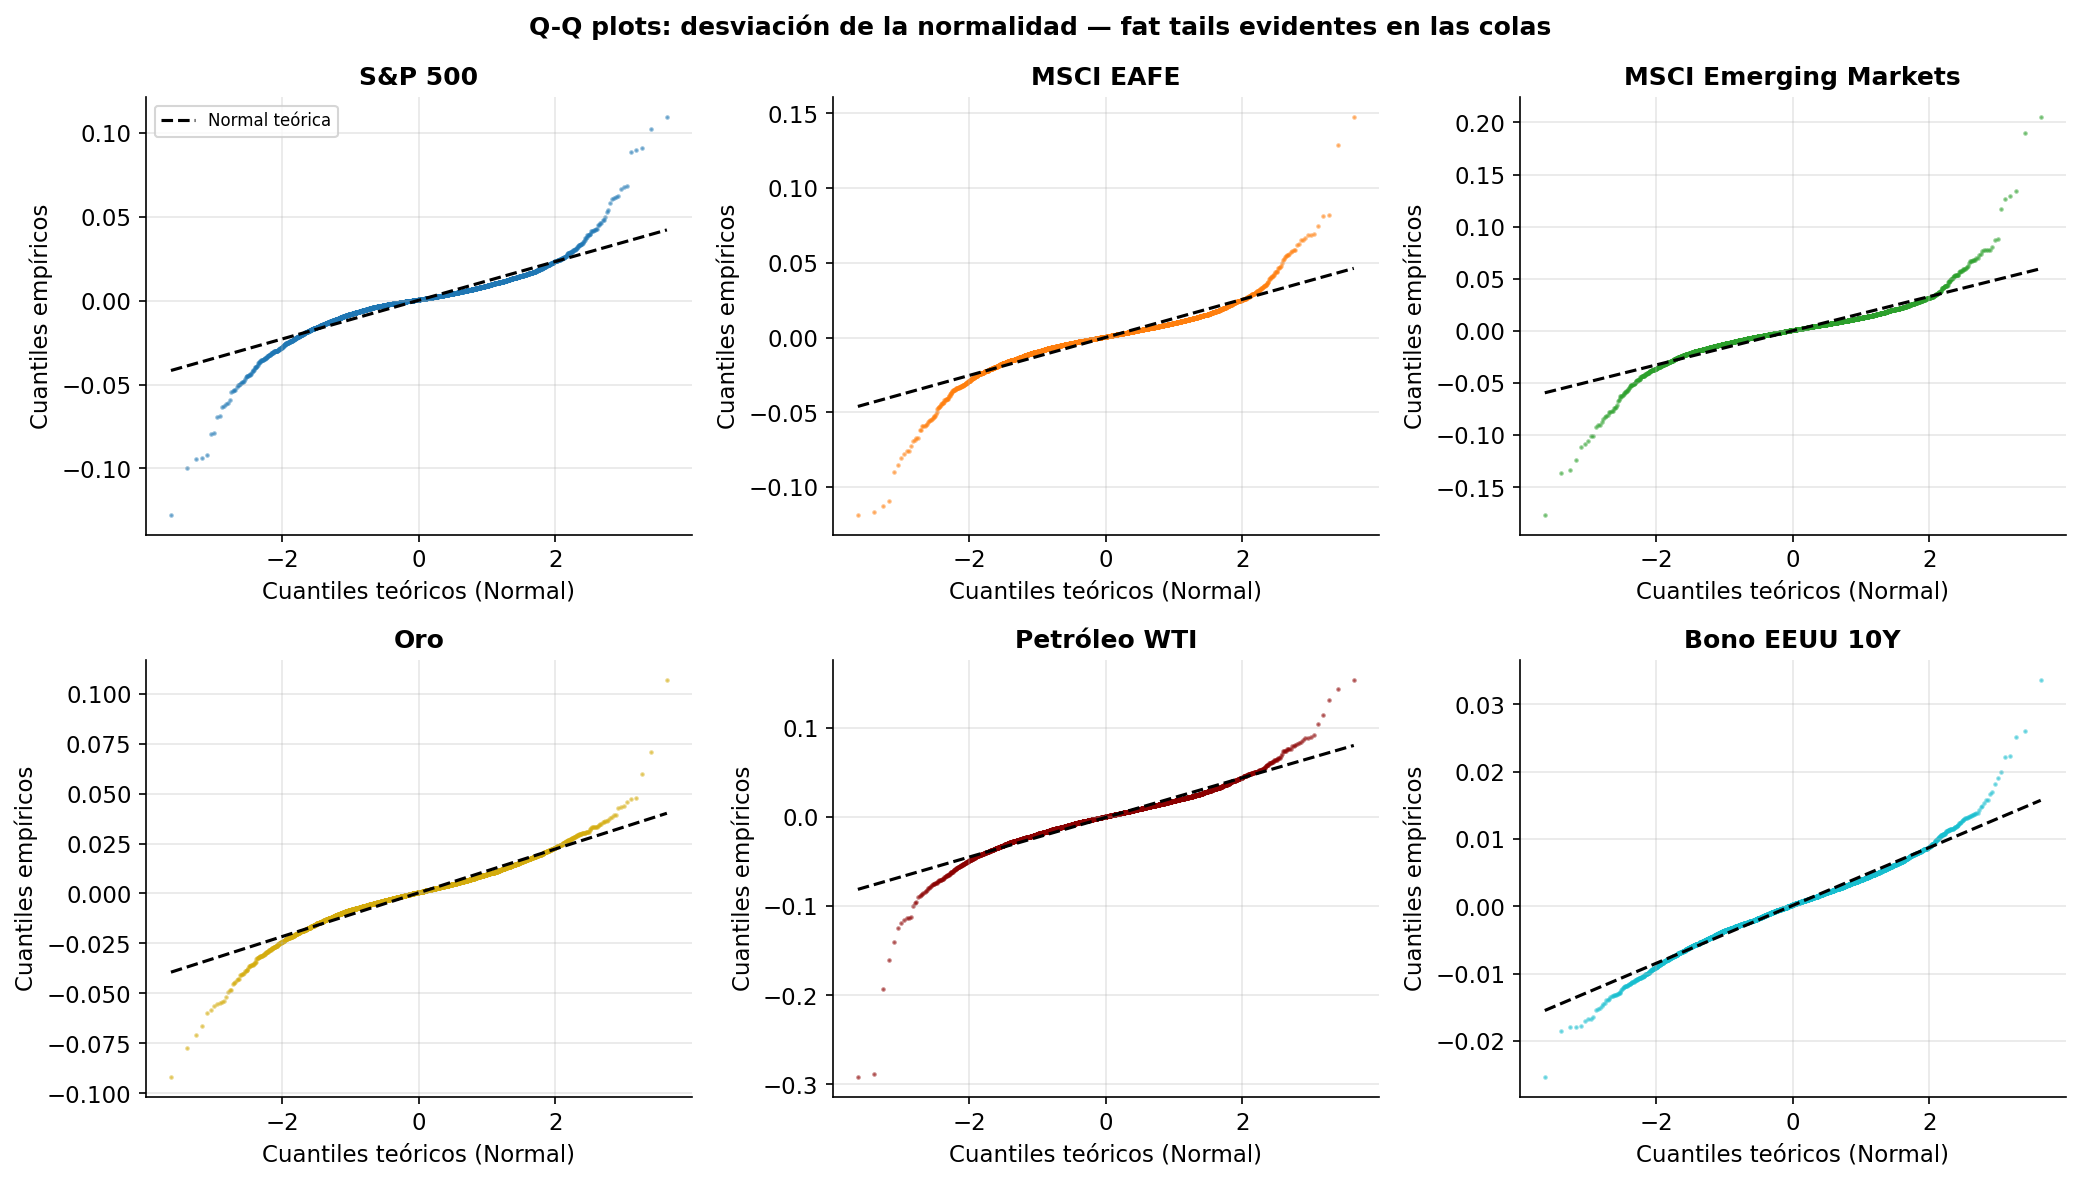

Fig 7 guardada ✓


In [22]:
# ─── Fig 7: Q-Q plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NAMES):
    ax = axes[i]
    r  = returns[col].dropna().values

    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    ax.scatter(osm, osr, color=COLORS[col], s=1.5, alpha=0.45)
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.5, label='Normal teórica')

    ax.set_title(LABELS[col], fontweight='bold')
    ax.set_xlabel('Cuantiles teóricos (Normal)')
    ax.set_ylabel('Cuantiles empíricos')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Q-Q plots: desviación de la normalidad — fat tails evidentes en las colas',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/fig7_qqplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 7 guardada ✓')

## 10 — Drawdown acumulado

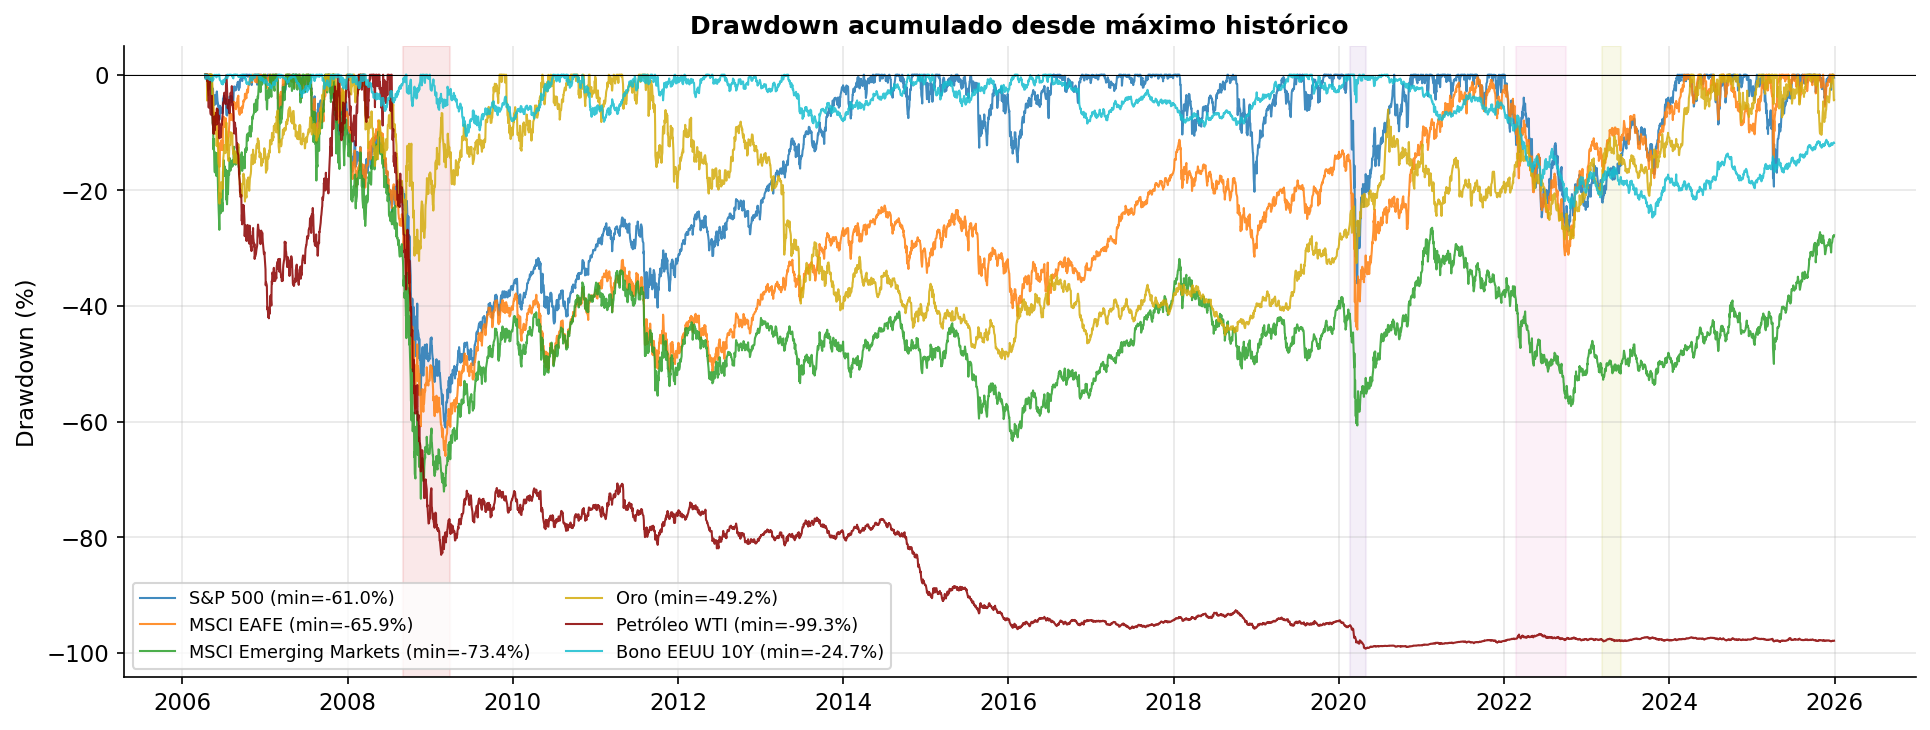

=== MÁXIMO DRAWDOWN POR ACTIVO ===
  S&P 500                     :  -61.03%
  MSCI EAFE                   :  -65.94%
  MSCI Emerging Markets       :  -73.35%
  Oro                         :  -49.22%
  Petróleo WTI                :  -99.29%
  Bono EEUU 10Y               :  -24.71%
Fig 8 guardada ✓


In [23]:
# ─── Fig 8: Drawdown ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

max_dd = {}
for col in NAMES:
    price    = (1 + returns[col]).cumprod()
    roll_max = price.cummax()
    dd       = (price - roll_max) / roll_max * 100
    max_dd[LABELS[col]] = round(dd.min(), 2)
    ax.plot(dd.index, dd.values,
            label=f'{LABELS[col]} (min={dd.min():.1f}%)',
            color=COLORS[col], lw=1.0, alpha=0.85)

shade_crisis(ax, alpha=0.10)
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Drawdown acumulado desde máximo histórico', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(ncol=2, fontsize=8.5)
format_xaxis(ax)
plt.tight_layout()
plt.savefig(f'{OUT}/fig8_drawdown.png', bbox_inches='tight', dpi=150)
plt.show()

print('=== MÁXIMO DRAWDOWN POR ACTIVO ===')
for k, v in max_dd.items():
    print(f'  {k:28s}: {v:7.2f}%')
print('Fig 8 guardada ✓')

## 11 — ACF de retornos cuadráticos (efecto GARCH)

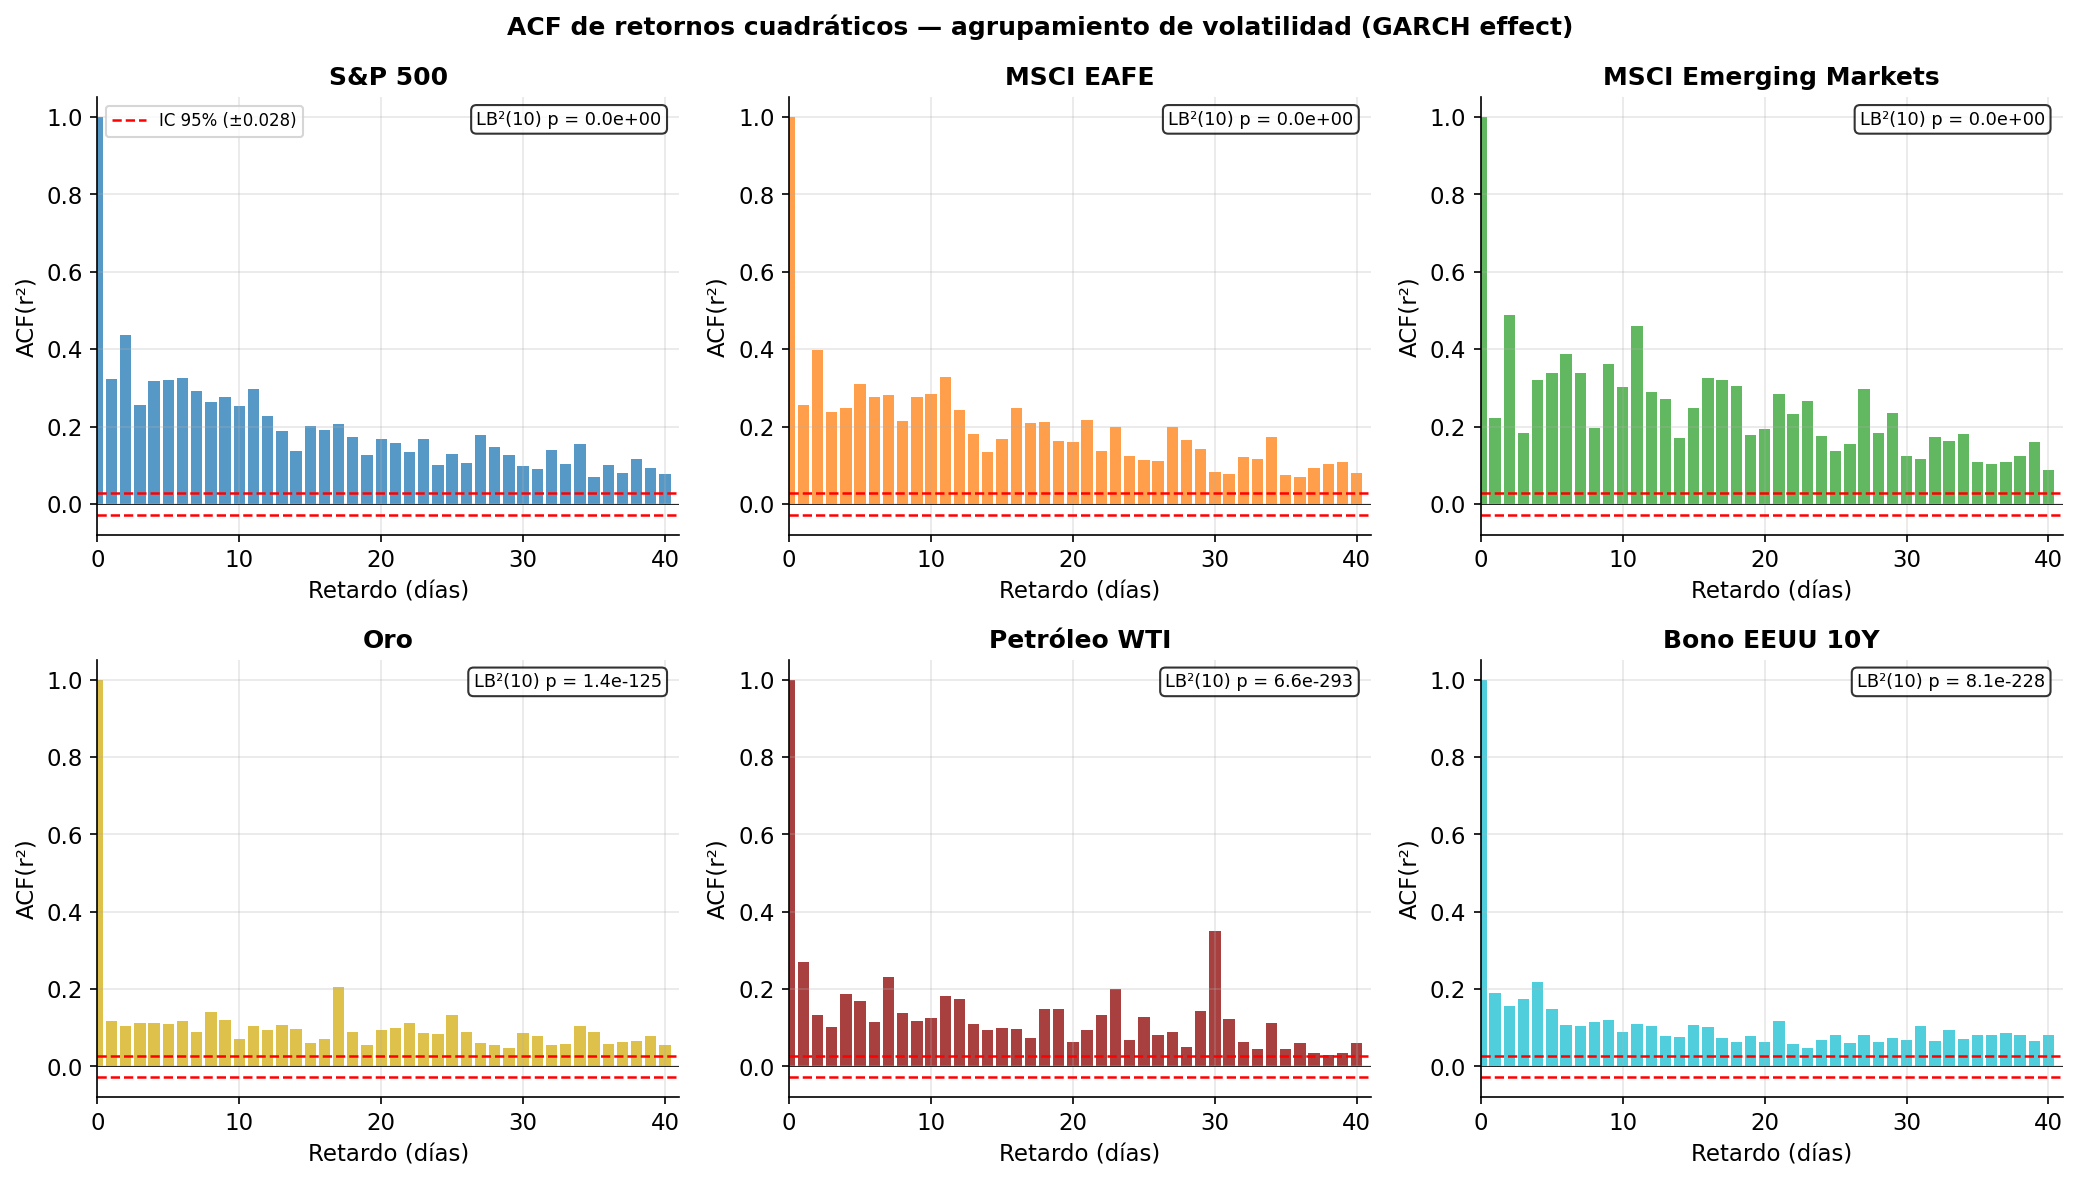

Fig 9 guardada ✓


In [24]:
# ─── Fig 9: ACF de r² ─────────────────────────────────────────────────────
MAX_LAG = 40
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(NAMES):
    ax  = axes[i]
    r2  = returns[col].dropna().values ** 2
    n_r = len(r2)

    acf_vals = acf(r2, nlags=MAX_LAG, fft=True)
    ci = 1.96 / np.sqrt(n_r)

    ax.bar(range(len(acf_vals)), acf_vals, color=COLORS[col], alpha=0.75, width=0.8)
    ax.axhline( ci, color='red', ls='--', lw=1.2)
    ax.axhline(-ci, color='red', ls='--', lw=1.2, label=f'IC 95% (±{ci:.3f})')
    ax.axhline( 0,  color='black', lw=0.4)

    lb = acorr_ljungbox(r2, lags=10, return_df=True)
    lb_p = lb['lb_pvalue'].iloc[-1]
    ax.text(0.97, 0.97, f'LB²(10) p = {lb_p:.1e}',
            transform=ax.transAxes, fontsize=8.5, va='top', ha='right',
            bbox=dict(boxstyle='round', fc='white', alpha=0.80))

    ax.set_title(LABELS[col], fontweight='bold')
    ax.set_xlabel('Retardo (días)')
    ax.set_ylabel('ACF(r²)')
    ax.set_xlim(0, MAX_LAG + 1)
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('ACF de retornos cuadráticos — agrupamiento de volatilidad (GARCH effect)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUT}/fig9_acf_cuadrados.png', bbox_inches='tight', dpi=150)
plt.show()
print('Fig 9 guardada ✓')

## 12 — Exportación: tabla-resumen y listado de figuras

In [25]:
# ─── Guardar todas las tablas ─────────────────────────────────────────────
desc.to_csv(f'{OUT}/tabla_estadisticos_descriptivos.csv', encoding='utf-8-sig')
df_regime_stats.to_csv(f'{OUT}/tabla_stats_por_regimen.csv', encoding='utf-8-sig', index=False)
corr_global.to_csv(f'{OUT}/correlaciones_global.csv', encoding='utf-8-sig')
corr_low.to_csv(f'{OUT}/correlaciones_baja_vol.csv', encoding='utf-8-sig')
corr_stress.to_csv(f'{OUT}/correlaciones_estres.csv', encoding='utf-8-sig')

# ─── Resumen final ─────────────────────────────────────────────────────────
print('=== RESUMEN EDA COMPLETADO ===')
print(f'  Periodo analizado : {returns.index[0].date()} → {returns.index[-1].date()}')
print(f'  Días hábiles      : {len(returns):,}')
print(f'  Activos           : {len(NAMES)}')
print()
print('  REGÍMENES:')
for rname in ['Baja volatilidad', 'Volatilidad moderada', 'Estrés financiero']:
    n = (regime == rname).sum()
    print(f'    {rname:25s}: {n:5d} días ({n/len(regime)*100:.1f}%)')
print()
print(f'  Frobenius (stress−low corr) : {frob:.4f}')
print()
print('  PROPIEDADES ESTADÍSTICAS CONFIRMADAS:')
print('    ✓ Fat tails (curtosis exceso > 0 en todos los activos)')
print('    ✓ No normalidad (JB p < 0.05 en todos los activos)')
print('    ✓ Estacionariedad (ADF p < 0.05 en todos los activos)')
print('    ✓ Agrupamiento de volatilidad (LB² p < 0.05 en todos los activos)')
print('    ✓ Aumento de correlaciones en estrés (Frobenius > 0)')
print()
print('  FIGURAS GENERADAS:')
for f in sorted(os.listdir(OUT)):
    if f.endswith('.png'):
        print(f'    {f}')
print()
print('  TABLAS CSV GUARDADAS:')
for f in sorted(os.listdir(OUT)):
    if f.endswith('.csv'):
        print(f'    {f}')

=== RESUMEN EDA COMPLETADO ===
  Periodo analizado : 2006-04-11 → 2025-12-30
  Días hábiles      : 4,962
  Activos           : 6

  REGÍMENES:
    Baja volatilidad         :  3228 días (65.1%)
    Volatilidad moderada     :  1287 días (25.9%)
    Estrés financiero        :   447 días (9.0%)

  Frobenius (stress−low corr) : 1.0913

  PROPIEDADES ESTADÍSTICAS CONFIRMADAS:
    ✓ Fat tails (curtosis exceso > 0 en todos los activos)
    ✓ No normalidad (JB p < 0.05 en todos los activos)
    ✓ Estacionariedad (ADF p < 0.05 en todos los activos)
    ✓ Agrupamiento de volatilidad (LB² p < 0.05 en todos los activos)
    ✓ Aumento de correlaciones en estrés (Frobenius > 0)

  FIGURAS GENERADAS:
    fig1_precios_normalizados.png
    fig2_retornos_diarios.png
    fig3_volatilidad_rolling.png
    fig4_vix_regimen.png
    fig5_correlaciones.png
    fig6_distribuciones.png
    fig7_qqplots.png
    fig8_drawdown.png
    fig9_acf_cuadrados.png

  TABLAS CSV GUARDADAS:
    correlaciones_baja_vol.csv
   

---
## Criterios de validación para TTS-GAN

Los datos sintéticos generados por TTS-GAN en la siguiente fase **deben reproducir** las siguientes propiedades para ser considerados estadísticamente válidos:

| Propiedad | Criterio de validación |
|---|---|
| Curtosis en exceso | > 0 en todos los activos |
| Sesgo | Dirección consistente con los datos reales |
| Jarque-Bera | p < 0.05 (no normalidad) |
| Ljung-Box r² | p < 0.05 (agrupamiento de volatilidad) |
| Frobenius (stress − low) | Comparable a los datos reales (±20%) |
| Correlaciones en estrés | Deben ser mayores que en baja volatilidad |

Estos criterios se aplican en la **Sección 5.2** del TFM (Generación y validación de datos sintéticos).